# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Phạm Minh Phú"  # TODO: Họ và tên
STUDENT_ID = "2550187"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phạm Minh Phú (2550187)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\minhphu\ML lab\python_ws\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
# exp_logits = ...
exp_logits = np.exp(shifted_logits)
# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)
# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)
print(shifted_logits)
print(class_probabilities)
print(predicted_classes)
print(confidence_scores)

[[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
[[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
[0 1 2 0]
[0.65900114 0.66524096 0.97555875 0.33333333]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis=0)
# train_feature_std = ...
train_feature_std = np.std(X_train, axis=0)
# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
correct_mask = predicted_classes == true_labels
# high_confidence_mask = ...
high_confidence_mask = confidence_scores > 0.7
# review_mask = ...
review_mask = (~correct_mask) | (~high_confidence_mask)
# review_indices = ...
review_indicies = np.where(review_mask)[0]
print(f"predict:    {predicted_classes}")
print(f"confidence: {confidence_scores}")
print(f"true:       {true_labels}")
print(review_indicies)

predict:    [0 1 2 0]
confidence: [0.65900114 0.66524096 0.97555875 0.33333333]
true:       [0 2 2 1]
[0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# normalized_batch = ...
from numpy import float32


normalized_batch = image_batch_uint8.astype(float32) / 255.0
print(f"--------normalized_batch: \n{normalized_batch}\n")
# augmented_batch = ...
augmented_batch = normalized_batch.copy()
augmented_batch = augmented_batch[ : , : , : :-1, :]
print(f"-------------augmented_batch: \n{augmented_batch}\n")
# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0] = 1.0
print(f"----------augmented_batch: \n{augmented_batch}\n")

--------normalized_batch: 
[[[[0.         0.00392157 0.00784314]
   [0.01176471 0.01568628 0.01960784]
   [0.02352941 0.02745098 0.03137255]
   [0.03529412 0.03921569 0.04313726]]

  [[0.04705882 0.05098039 0.05490196]
   [0.05882353 0.0627451  0.06666667]
   [0.07058824 0.07450981 0.07843138]
   [0.08235294 0.08627451 0.09019608]]

  [[0.09411765 0.09803922 0.10196079]
   [0.10588235 0.10980392 0.11372549]
   [0.11764706 0.12156863 0.1254902 ]
   [0.12941177 0.13333334 0.13725491]]

  [[0.14117648 0.14509805 0.14901961]
   [0.15294118 0.15686275 0.16078432]
   [0.16470589 0.16862746 0.17254902]
   [0.1764706  0.18039216 0.18431373]]]


 [[[0.1882353  0.19215687 0.19607843]
   [0.2        0.20392157 0.20784314]
   [0.21176471 0.21568628 0.21960784]
   [0.22352941 0.22745098 0.23137255]]

  [[0.23529412 0.23921569 0.24313726]
   [0.24705882 0.2509804  0.25490198]
   [0.25882354 0.2627451  0.26666668]
   [0.27058825 0.27450982 0.2784314 ]]

  [[0.28235295 0.28627452 0.2901961 ]
   [0.294

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Giá trị thiếu trong `automobile_raw.csv` được giữ dưới dạng ký hiệu `?`.
3. `symboling` là mức đánh giá rủi ro bảo hiểm, kiểu dữ liệu là int và thuộc đoạn từ -3 đến 3

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH.resolve())
# raw_shape = ...
raw_shape = raw_df.shape
print(raw_shape)
# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == '?').sum().sum()
print(f"missing values: {raw_missing_marker_count}")


(205, 26)
missing values: 59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace('?', np.nan)
# for column in NUMERIC_COLUMNS:
#     ...
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], downcast="float")
print(df_clean.dtypes)
# missing_by_column = ...
missing_by_column = df_clean.isna().sum()
print(missing_by_column)

symboling            float32
normalized_losses    float32
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float32
length               float32
width                float32
height               float32
curb_weight          float32
engine_type              str
num_cylinders            str
engine_size          float32
fuel_system              str
bore                 float32
stroke               float32
compression_ratio    float32
horsepower           float32
peak_rpm             float32
city_mpg             float32
highway_mpg          float32
price                float32
dtype: object
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base      

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**
Các numeric columns là dữ liệu của các đặc trưng có đơn vị tính khác nhau và mỗi đặc trưng cũng có những ý nghĩa riêng.
Lấy ví dụ 2 cột là wheel_base và bore, đường kính xi lanh bé hơn rất nhiều so với khoảng cách giưã tâm hai trục bánh xe dù cho cùng đơn vị tính toán. Ta không thể lấy được 1 giá trị chung nào thỏa không phải là outlier của cả 2 cột này vì lí do trên.

Trong bài EDA này, mục tiêu của bài toàn là tập trung vào feature price, phân tích xu hướng của price dựa trên các feature khác. Do đó nếu ta chọn fill giá trị cho missing value thì đã ngầm xác định xu hướng của price, tạo số liệu giả trong khi feature price là mục tiêu ta cần phân tích. Vì thế lựa chọn drop sẽ phù hợp hơn, bảo toàn feature cần phân tích là true label. Bên cạnh đó price chỉ có 4 missing value nên khi lựa chọn drop cũng không quá ảnh hưởng đến chất lượng của dữ liệu thật.

Cột normalized_losses thiếu 41 dòng dữ liệu tức khoảng 20%. 
<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
# analysis_df = ...
from numpy import float64


analysis_df = df_clean[AUTO_FEATURES].dropna()
# X_auto = ...
X_auto = analysis_df.to_numpy(dtype=float64, copy=True)
# auto_feature_mean = ...
auto_feature_mean = np.mean(X_auto, axis=0)
# auto_feature_std = ...
auto_feature_std = np.std(X_auto, axis=0)
# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index('price')
# price_z = ...
price_z = X_auto_scaled[ : , price_index]
# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2
# price_outliers = ...
price_outliers = analysis_df[price_outlier_mask]
print(price_outliers)
print(X_auto_scaled[price_outlier_mask])


     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
15        3230.0        209.0       182.0      16.0         22.0  30760.0
16        3380.0        209.0       182.0      16.0         22.0  41315.0
17        3505.0        209.0       182.0      15.0         20.0  36880.0
47        4066.0        258.0       176.0      15.0         19.0  32250.0
48        4066.0        258.0       176.0      15.0         19.0  35550.0
49        3950.0        326.0       262.0      13.0         17.0  36000.0
70        3770.0        183.0       123.0      22.0         25.0  31600.0
71        3740.0        234.0       155.0      16.0         18.0  34184.0
72        3685.0        234.0       155.0      16.0         18.0  35056.0
73        3900.0        308.0       184.0      14.0         16.0  40960.0
74        3715.0        304.0       184.0      14.0         16.0  45400.0
126       2756.0        194.0       207.0      17.0         25.0  32528.0
127       2756.0        194.0       20

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
# engine_price_corr = ...
corr_matrix = np.corrcoef(X_auto_scaled, rowvar=False)
engine_price_corr = corr_matrix[AUTO_FEATURES.index('engine_size')][AUTO_FEATURES.index('price')]
print(f"engine_price_corr = {engine_price_corr}")
# price_by_body_style = ...
price_by_body_style = df_clean.groupby(by=['body_style'])['price'].mean().sort_values()
print(price_by_body_style)

engine_price_corr = 0.8738869517981525
body_style
hatchback       9957.441406
wagon          12371.959961
sedan          14459.754883
convertible    21890.500000
hardtop        22208.500000
Name: price, dtype: float32


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

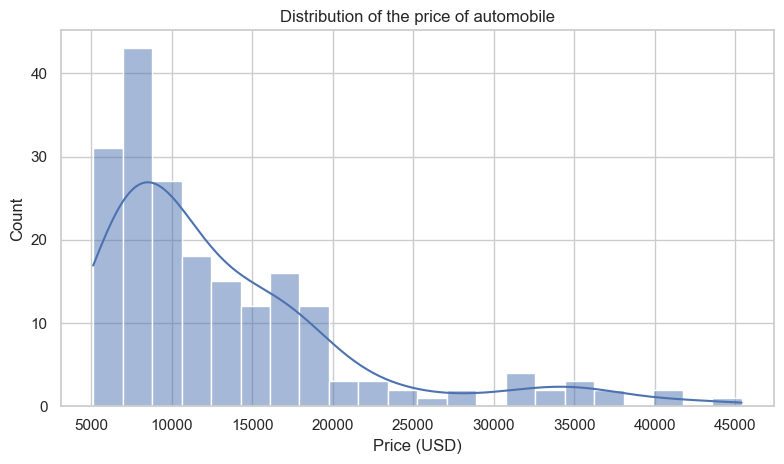

0.25     7775.0
0.50    10345.0
0.75    16501.5
Name: price, dtype: float64
45400.0


In [20]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data=analysis_df, x='price', kde=True, bins=22)
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.title("Distribution of the price of automobile")
plt.tight_layout()
plt.show()
print(analysis_df['price'].quantile([0.25, 0.5, 0.75]))
print(analysis_df['price'].max())

**Nhận xét:** <!-- 1--2 câu -->

Phân phối của giá xe chỉ có một đỉnh và lệch phải rõ rệt, cho thấy phần lớn các giá có mức giá thấp đến trung bình, chỉ có số ít có thể là xe hạng sang nên mức giá rất cao. Giá xe tập trung quanh mức 10,000 USD, đồng thời dữ liệu cũng chứa nhiều outlier ở đuôi phải với mức giá cao nhất 45,400 USD vượt ngưỡng Q3 + 1.5*IQR. Vì phân phối lệch phải rõ rệt này nên ta cần cẩn thận khi lựa chọn mean để phân tích về sau vì bị ảnh hưởng bởi outlier rất nhiều. Tuy nhiên cũng chưa nên loại bỏ ngay các  outlier này vì đây có thể là dữ liệu chứa các feature của xe hạng sang.

## M2.2 Dataset có cân bằng theo body style không?

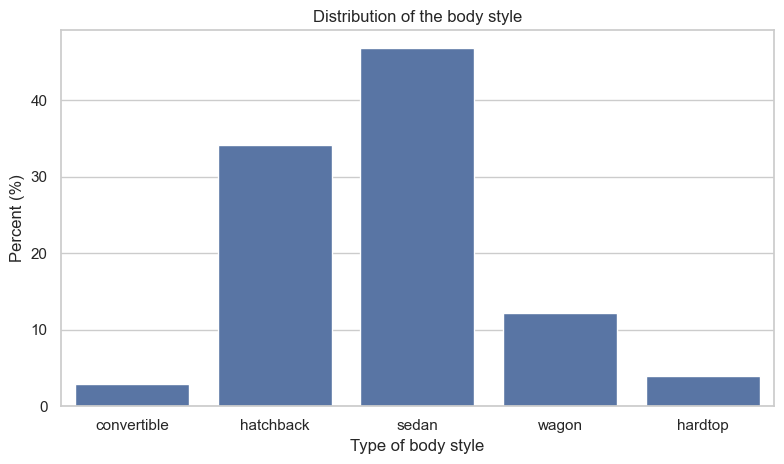

In [21]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x='body_style', stat='percent')
plt.xlabel("Type of body style")
plt.ylabel("Percent (%)")
plt.title("Distribution of the body style")
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Số lượng của từng kiểu dáng xe trong bộ dataset này không cân bằng. Dựa vào biểu đồ có thể thấy hatchback và sedan chiểm phần trăm rất lớn, sedan đặc biệt lớn khi chiếm tới gần 50%. Kết hợp với thống kê price_by_body_style ở bài D5 thì kết quả hiện tại hoàn toàn phù hợp với biểu đồ phân phối của price ở bài M2.1. Hai kiểu dáng convertible và hardtop có mức giá trung bình cao nhất nhưng chỉ chiếm một số lượng rất nhỏ trong bộ dữ liệu này, trong khi hatchback và sedan mức giá trung bình không cao. Vì thế phân phối giá lệch phải rõ rệt là điều dễ hiễu.

## M2.3 Price khác nhau theo body style ra sao?

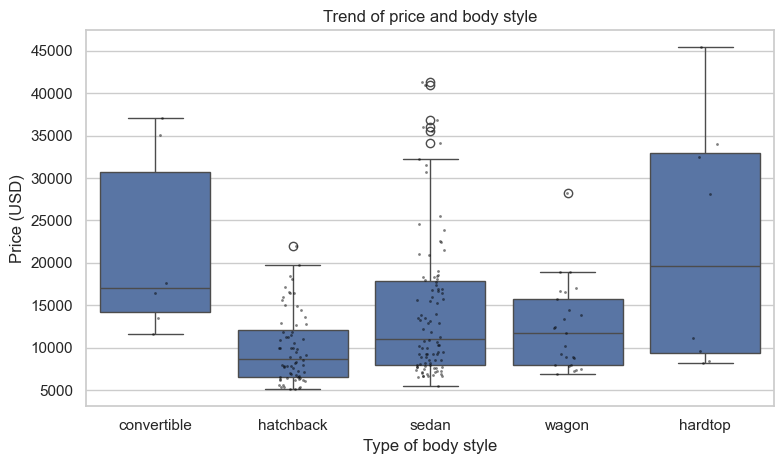

In [22]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price')
sns.stripplot(data=df_clean, x='body_style', y='price', alpha=0.5, color='black', size=2)
plt.xlabel("Type of body style")
plt.ylabel("Price (USD)")
plt.title("Trend of price and body style")
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Biểu đồ boxplot này hoàn toàn hợp lí với những phân tích mở mục M2.2 và kết quả tính toán ở D5. Giá trị của các xe có kiểu dáng conertible và hardtop cao hơn rất nhiều so với 3 kiểu xe còn lại, thế nhưng trong dataset chỉ có rất ít dữ liệu cùa 2 kiểu dáng xe này. Dòng xe sedan chiếm phần lớn trong bộ dữ liệu, mức giá trung bình không cao, tuy nhiên có rất nhiều outlier có mức giá thậm chí còn cao hơn phần lớn các dòng xe convetible và hardtop. Điều này có thể phản ánh trong bộ dự liệu thật sự chứa dữ liệu của các xe hạng sang do dòng sedan là rất phổ biến ở phân khúc này.

## M2.4 Engine size liên quan thế nào tới price?

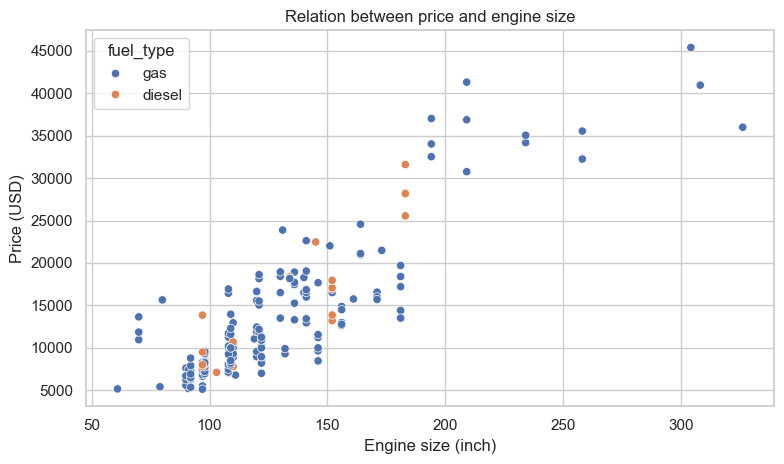

enginesize_price_corr = 0.8738869517981525


In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type')
plt.title("Relation between price and engine size")
plt.xlabel("Engine size (inch)")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()
print(f"enginesize_price_corr = {corr_matrix[AUTO_FEATURES.index('engine_size')][AUTO_FEATURES.index('price')]}")

**Nhận xét:** <!-- 1--2 câu -->

Feature price và engine_size có độ tương quan dương khá cao, ở mức 0.87. Điều này cũng được thể hiện rõ rệt ở scatterplot trên, khi đại lượng engine_size tăng, price cũng tăng. Cũng chính vì tính chất tập trung nhiều ở giá trị thấp đến trung của price, engine_size cũng có tính chất tương tự. Dù vậy ở cùng một mức engine size, price có biên độ rất lớn, giá trị lớn nhất có thể lớn gấp đôi giá trị bé nhất. Điều này phản ảnh giá trị của một chiếc xe còn phụ thuộc vào nhiều yếu tố khác như công suất, kiểu thân xe hay hãng sản xuất.

## M2.5 Các feature numeric tương quan ra sao?

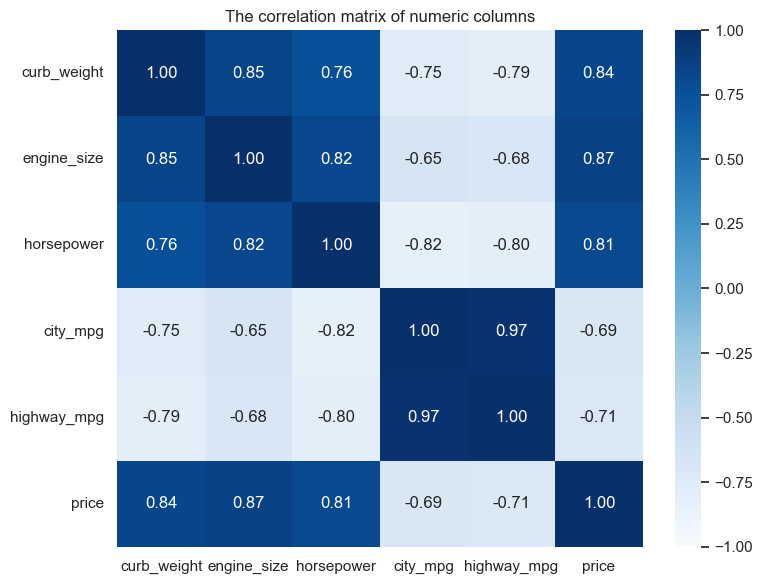

In [24]:
# TODO M2.5: correlation heatmap
fig, ax = plt.subplots(1,1, figsize=(8,6))
sns.heatmap(data=analysis_df.corr(), cmap="Blues", annot=True, fmt='.2f', ax=ax, vmin=-1)
plt.title("The correlation matrix of numeric columns")
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Heatmap cho thấy engine_size, curb_weight và horsepower có tương quan dương mạnh với price, trong đó engine_size là biến có mối liên hệ mạnh nhất hệ số tương quan là 0.87. Ngược lại, city_mpg và highway_mpg có tương quan âm với price, cho thấy các xe tiết kiệm nhiên liệu hơn thường có giá thấp hơn. Ngoài ra, city_mpg và highway_mpg có tương quan rất cao với hệ số tương quan 0.97, cũng như engine_size, horsepower và curb_weight tương quan mạnh với nhau, cho thấy tồn tại hiện tượng đa cộng tuyến giữa một số biến đầu vào.

## M2.6 Công suất lớn ảnh hưởng ra sao tới khả năng tiết kiệm nhiên liệu?

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

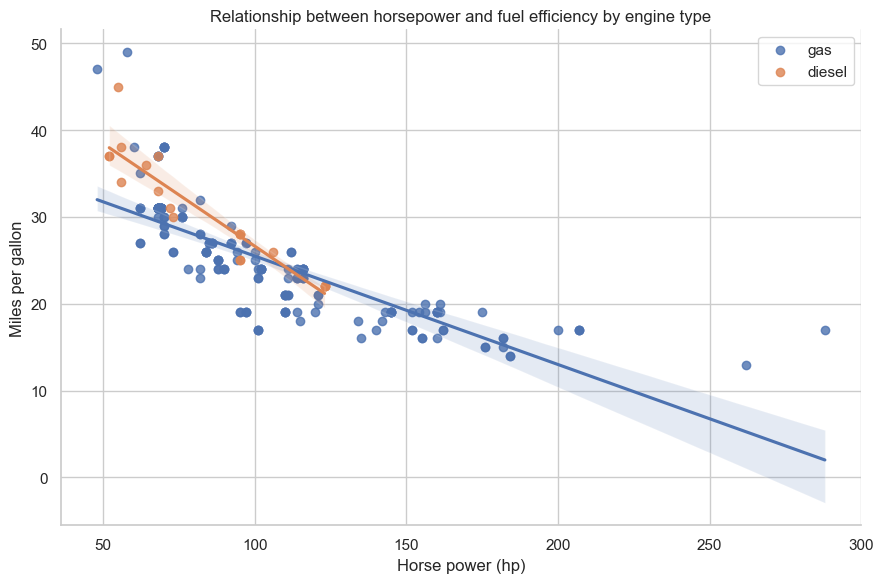

In [68]:
# TODO M2.6: biểu đồ tự chọn
sns.lmplot(data=df_clean, x='horsepower', y='city_mpg', hue='fuel_type', height=6, aspect=1.5, legend=False)
plt.title("Relationship between horsepower and fuel efficiency by engine type")
plt.xlabel("Horse power (hp)")
plt.ylabel("Miles per gallon")
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Biểu đồ đã thể hiện một cách rõ rệt sự đánh đổi giữa công suất động cơ và khả năng tiết kiệm nhiên liệu, công suất càng lớn thì mức tiêu thụ nhiên liệu càng lớn vì thế khả năng tiết kiệm nhiên liệu càng giảm. Quan trọng hơn, biểu đồ cho thấy ở cùng một mức công suất thì động cơ diesel tiết kiệm nhiên liệu hơn so với động cơ xăng. Chính vì thế dòng xe diesel chỉ tập trung ở phân khúc công suất thấp đến trung bình nhằm tối ưu về mặt kinh tế, còn dòng xe công suất lớn hoàn toàn chạy bằng xăng và cực kỳ hao nhiên liệu.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
Qua quá trình EDA có thể thấy bộ dữ liệu đã phản ánh khá rõ mối quan hệ giữa các đặc trưng của ô tô năm 1985. Đáng chú ý nhất là sự đánh đổi giữa công suất động cơ và khả năng tiết kiệm nhiên liệu. Khi horsepower tăng thì city_mpg giảm rõ rệt, cho thấy các xe có công suất lớn thường tiêu thụ nhiều nhiên liệu hơn. Bên cạnh đó, ở cùng một mức công suất, động cơ Diesel vẫn có khả năng tiết kiệm nhiên liệu tốt hơn động cơ Gas. Điều này cũng giải thích vì sao các mẫu xe Diesel chủ yếu tập trung ở nhóm công suất thấp đến trung bình, trong khi các xe công suất rất lớn hầu như đều sử dụng động cơ xăng.

Tuy nhiên, bộ dữ liệu vẫn còn một số hạn chế cần lưu ý trước khi sử dụng cho các bước phân tích hoặc xây dựng mô hình. Hai đặc trưng city_mpg và highway_mpg có hệ số tương quan rất cao, gần như mang cùng một lượng thông tin nên việc giữ lại cả hai có thể làm tăng hiện tượng đa cộng tuyến và gây dư thừa dữ liệu. Ngoài ra, cột normalized_losses có hơn 20% giá trị bị thiếu, khiến việc phân tích mức tổn thất bảo hiểm hoặc so sánh với chỉ số symboling trở nên kém tin cậy hơn.

Một điểm cũng cần lưu ý là tương quan không đồng nghĩa với quan hệ nhân quả. Chẳng hạn, ở bài M2.4, engine_size có tương quan dương mạnh với price, nhưng điều đó không có nghĩa là chỉ cần tăng dung tích động cơ thì giá xe sẽ tăng tương ứng. Trên thực tế, các xe có động cơ lớn thường đi kèm nhiều đặc điểm khác như công suất cao hơn, cấu hình động cơ phức tạp hoặc thuộc phân khúc cao cấp, và chính những yếu tố này cùng tác động đến giá bán. Từ những kết quả EDA trên, một hướng phát triển hợp lý là xây dựng mô hình Machine Learning để dự đoán giá xe và đánh giá mức độ quan trọng của từng đặc trưng. Điều này không chỉ giúp hiểu rõ hơn các yếu tố ảnh hưởng đến giá mà còn hỗ trợ định hướng thiết kế và phân khúc sản phẩm phù hợp.